In [2]:
%pip install -q pandas numpy seaborn matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
sns.set_style("whitegrid")
pd.set_option("display.max_columns",40)

### Load Datasets

In [4]:
titanic=sns.load_dataset("titanic")

In [6]:
df=titanic

2. Numerical vs Numerical

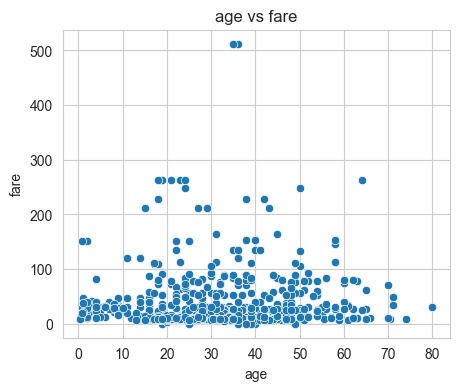

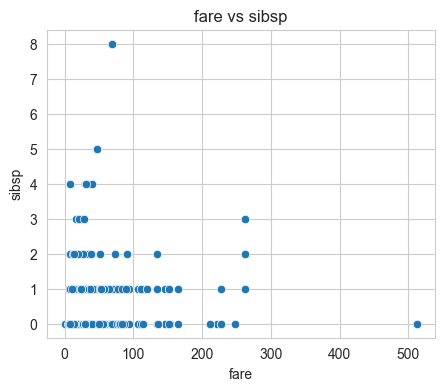

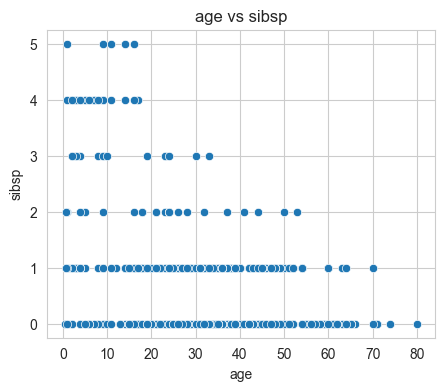

In [7]:
num_pairs={
    ("age","fare"),
    ("age","sibsp"),
    ("fare","sibsp")
}
for x,y in num_pairs:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[x],y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show() 

3.2 correlation Matrix

In [8]:
nums_cols=["age","fare","sibsp","parch"]


In [16]:
df_num=df[nums_cols].dropna()

In [17]:
print("correlation matrix:")
df_num.corr()
#-1 represent high negative correlation
# 1 represent high positive correlation

correlation matrix:


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [11]:
num_pairs={
    ("age","fare"),
    ("age","sibsp"),
    ("fare","sibsp")
}

In [21]:
print("Personr correlation with fare:")
for col in nums_cols :
    if col!="fare":
        r,p=pearsonr(df_num[col],df_num["fare"])
        print(f"{col} vs fare:r= {r:.3f}: p={p:.3f}")

Personr correlation with fare:
age vs fare:r= 0.096: p=0.010
sibsp vs fare:r= 0.138: p=0.000
parch vs fare:r= 0.205: p=0.000


4. Numerical vs Categorical

boxplot


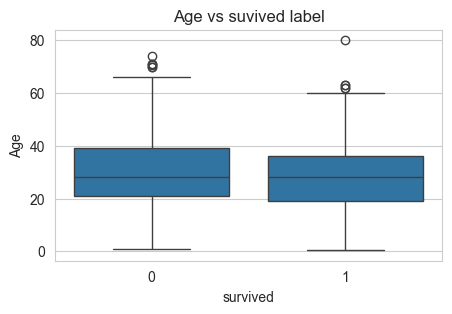

In [22]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["survived"],y=df["age"])
plt.xlabel("survived")
plt.ylabel("Age")
plt.title("Age vs suvived label")
plt.show()

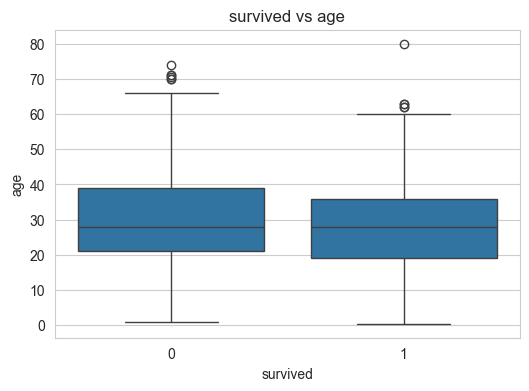

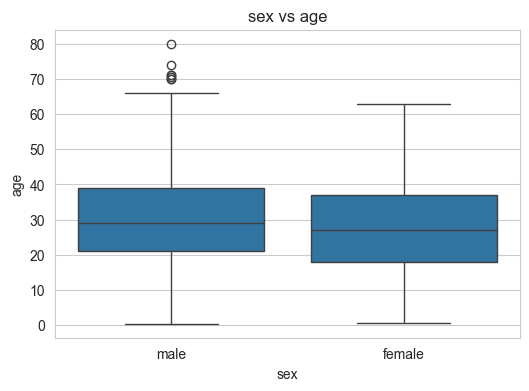

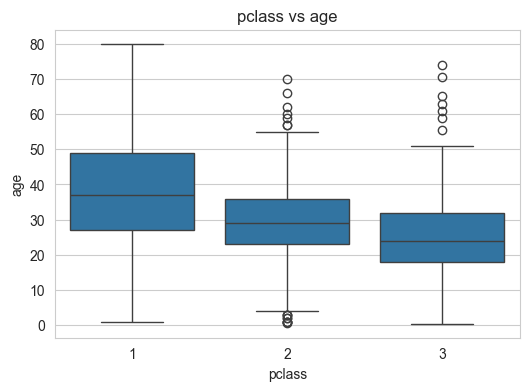

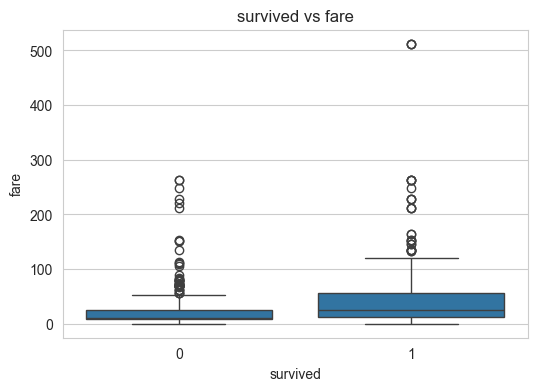

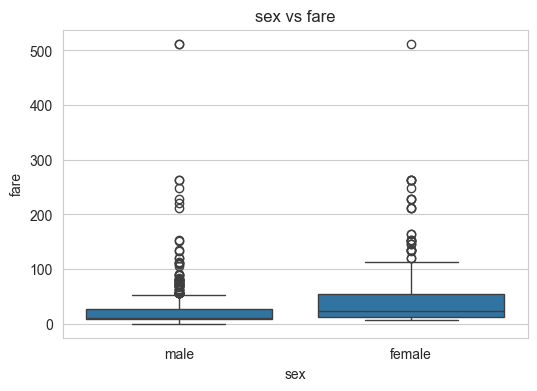

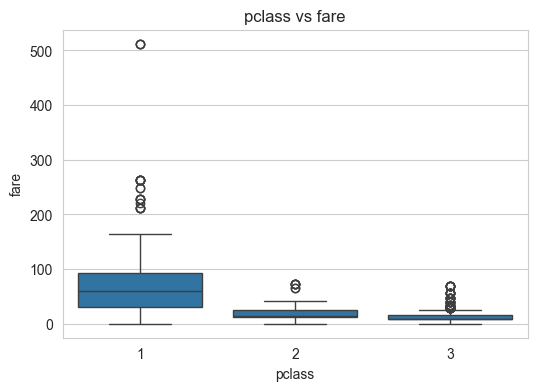

In [24]:
num_for_box=["age","fare"]
cat_for_box=["survived","sex","pclass"]
for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[cat],y=df[num])
        plt.title(f"{cat} vs {num}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

grouped statatics


In [29]:
df[nums_cols +["survived_label"]]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,NO
1,38.0,71.2833,1,0,yes
2,26.0,7.9250,0,0,yes
3,35.0,53.1000,1,0,yes
4,35.0,8.0500,0,0,NO
...,...,...,...,...,...
886,27.0,13.0000,0,0,NO
887,19.0,30.0000,0,0,yes
888,NaN,23.4500,1,2,NO
889,26.0,30.0000,0,0,yes


In [28]:
df["survived_label"]=df["survived"].map({0:"NO",1:"yes"})

In [33]:
df[nums_cols+["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
NO,30.626179,22.117887,0.553734,0.329690
yes,28.343690,48.395408,0.473684,0.464912


In [36]:
df[nums_cols].groupby("age").mean()


,fare,sibsp,parch
age,,,
0.42,8.5167,0.0,1.0
0.67,14.5000,1.0,1.0
0.75,19.2583,2.0,1.0
0.83,23.8750,0.5,1.5
0.92,151.5500,1.0,2.0
...,...,...,...
70.00,40.7500,0.5,0.5
70.50,7.7500,0.0,0.0
71.00,42.0792,0.0,0.0


In [37]:
for cat in ["survived_label","sex","pclass"]:
    print(f"Grouped by {cat}")
    print(df.groupby(cat)["fare"].describe())
    print("-"*50)

Grouped by survived_label
                count       mean        std  min      25%   50%   75%  \
survived_label                                                          
NO              549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0   
yes             342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0   

                     max  
survived_label            
NO              263.0000  
yes             512.3292  
--------------------------------------------------
Grouped by sex
        count       mean        std   min        25%   50%    75%       max
sex                                                                        
female  314.0  44.479818  57.997698  6.75  12.071875  23.0  55.00  512.3292
male    577.0  25.523893  43.138263  0.00   7.895800  10.5  26.55  512.3292
--------------------------------------------------
Grouped by pclass
        count       mean        std  min       25%      50%   75%       max
pclass                                                    

Categorical vs Categorical